<a href="https://colab.research.google.com/github/eiyu18/pcvk/blob/main/Week6_10_244107020181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

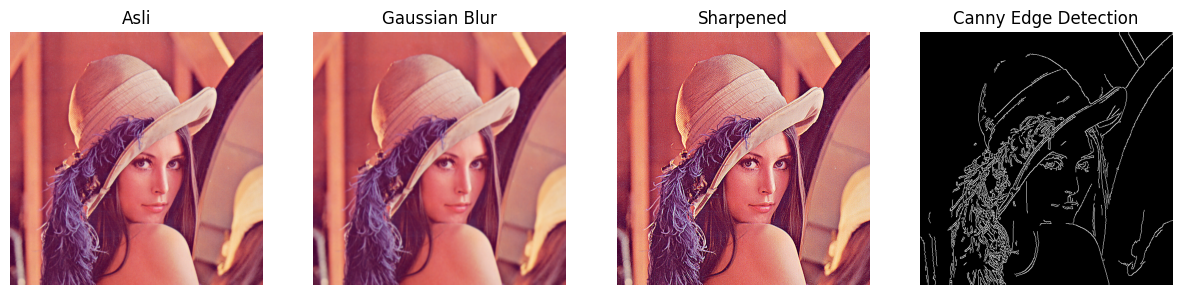

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/Lenna.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

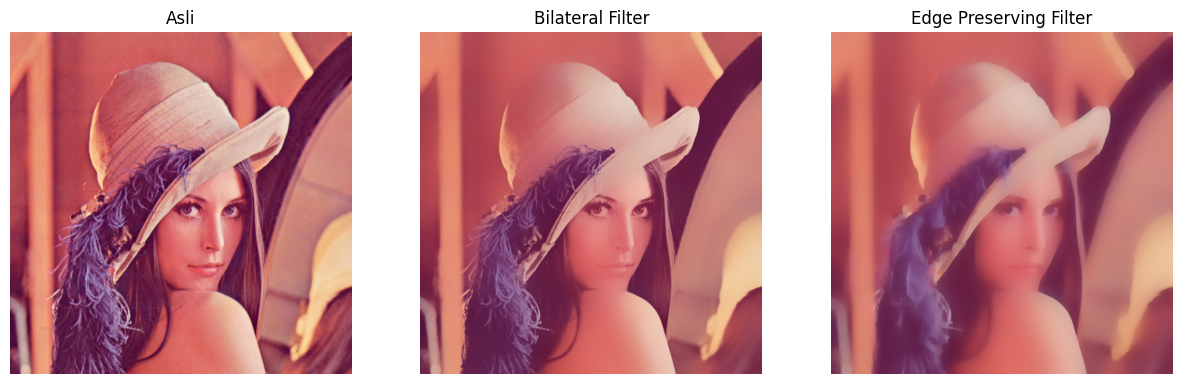

In [11]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/Lenna.png")

bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

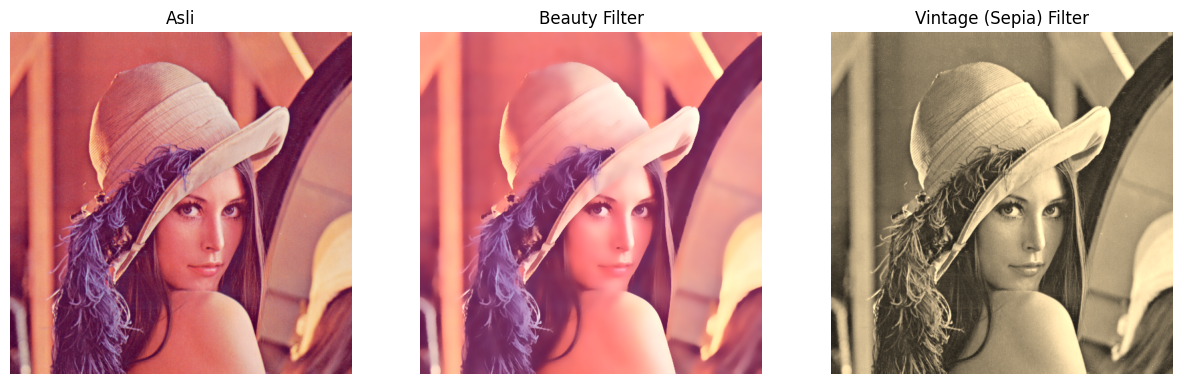

In [12]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/Lenna.png")

beauty = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

beauty = cv.convertScaleAbs(beauty, alpha=1.1, beta=15)

kernel_sepia = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])

vintage = cv.transform(img, kernel_sepia)

vintage = np.clip(vintage, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, vintage],
                  ["Asli", "Beauty Filter", "Vintage (Sepia) Filter"])

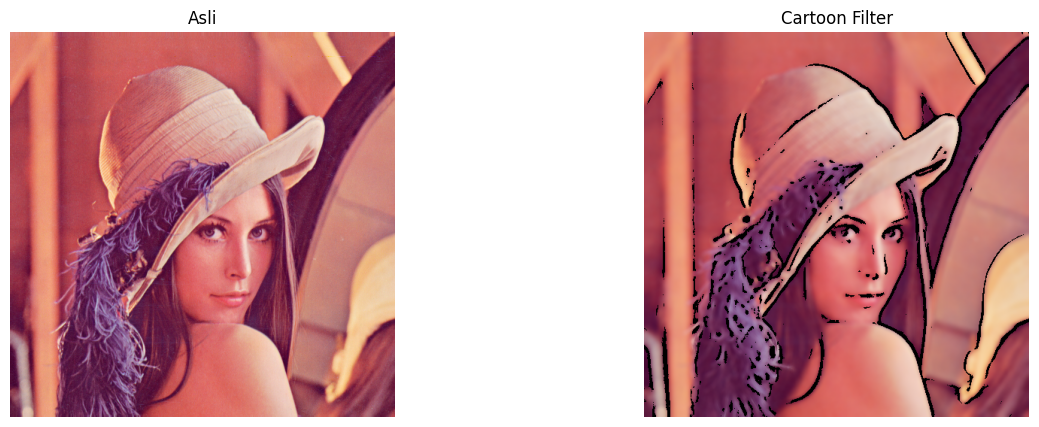

In [14]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/Lenna.png")

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

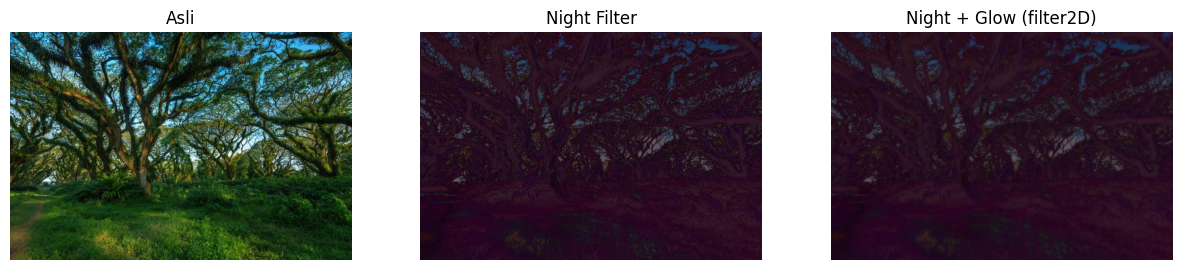

In [16]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/djawatan.jpg")

img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

night = cv.convertScaleAbs(img, alpha=0.6, beta =- 40)

blue_tint = np.full_like(night, (50, 0, 100))
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

night_glow= cv.addWeighted(night, 0.7, glow, 0.3,0)

show_side_by_side([img, night, night_glow],
["Asli", "Night Filter", "Night + Glow (filter2D)"])

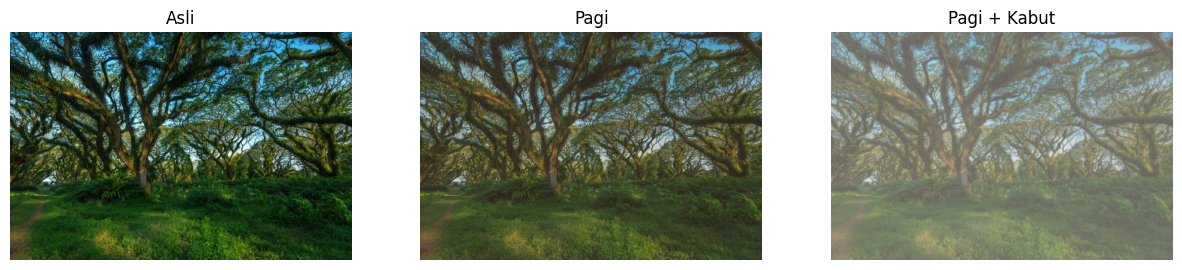

In [17]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/sample_data/djawatan.jpg")

alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
["Asli", "Pagi", "Pagi + Kabut"])

Task Practice

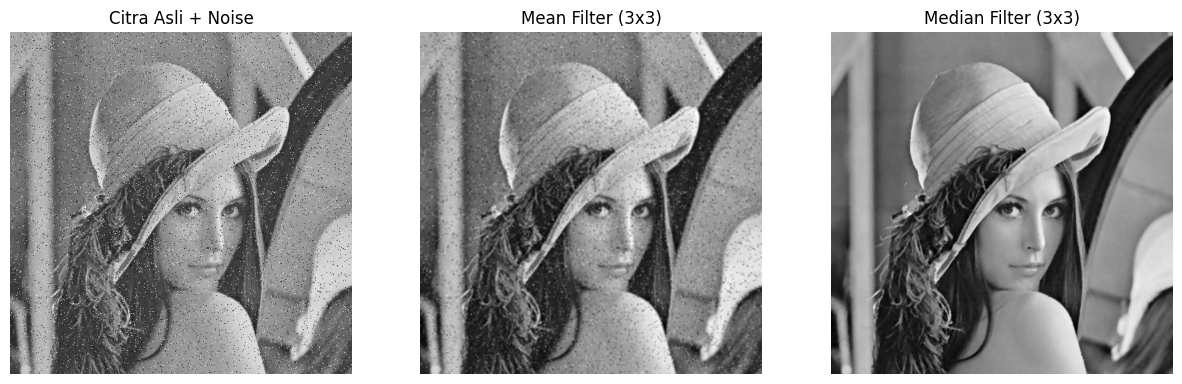

In [19]:
def add_salt_and_pepper_noise(image, prob=0.05):
    output = np.copy(image)
    black = 0
    white = 255
    probs = np.random.random(output.shape)
    output[probs < (prob / 2)] = black
    output[probs > 1 - (prob / 2)] = white
    return output

img = cv.imread("/content/sample_data/Lenna.png", cv.IMREAD_GRAYSCALE)

img_noise = add_salt_and_pepper_noise(img, prob=0.04)

mean_filtered = cv.blur(img_noise, (3, 3))
median_filtered = cv.medianBlur(img_noise, 3)

plt.figure(figsize=(15, 5))
titles = ["Citra Asli + Noise", "Mean Filter (3x3)", "Median Filter (3x3)"]
images = [img_noise, mean_filtered, median_filtered]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

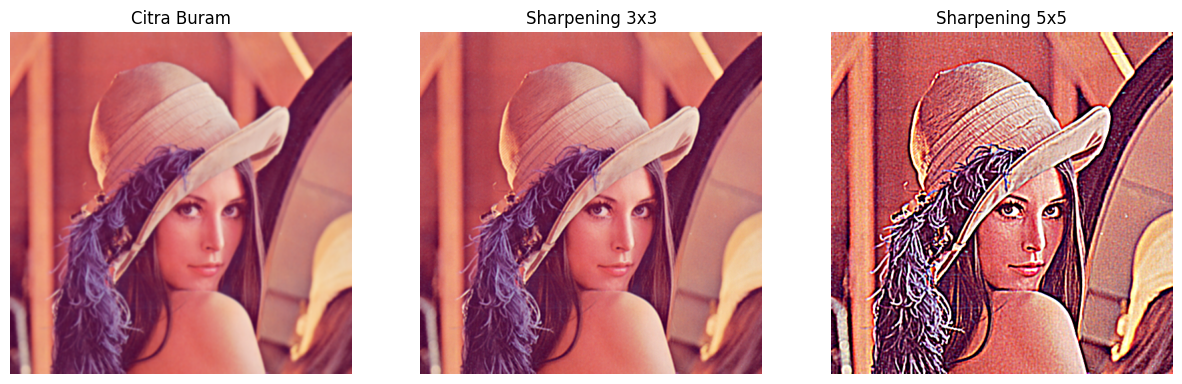

In [20]:
img_color = cv.imread("/content/sample_data/Lenna.png")
img_color = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
img_blurry = cv.GaussianBlur(img_color, (5, 5), 0)

kernel_3x3 = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])

kernel_5x5 = np.array([[-1, -1, -1, -1, -1],
                       [-1,  1,  1,  1, -1],
                       [-1,  1,  9,  1, -1],
                       [-1,  1,  1,  1, -1],
                       [-1, -1, -1, -1, -1]])

sharpened_3x3 = cv.filter2D(img_blurry, -1, kernel_3x3)
sharpened_5x5 = cv.filter2D(img_blurry, -1, kernel_5x5)

plt.figure(figsize=(15, 5))
titles = ["Citra Buram", "Sharpening 3x3", "Sharpening 5x5"]
images = [img_blurry, sharpened_3x3, sharpened_5x5]

for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

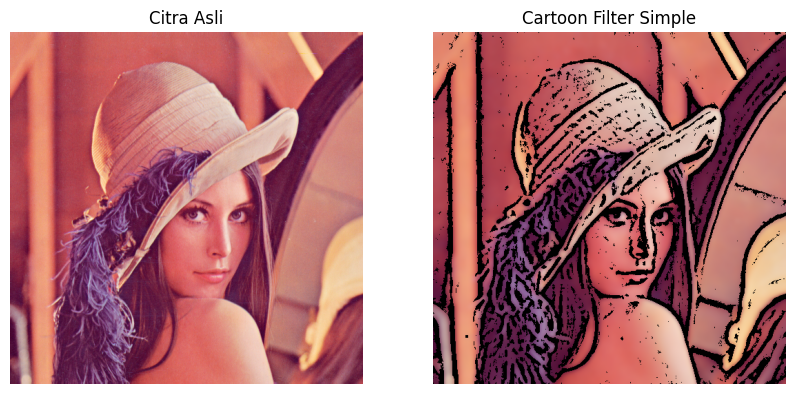

In [21]:
def cartoon(image):
    color = image
    for _ in range(2):
        color = cv.bilateralFilter(color, d=9, sigmaColor=250, sigmaSpace=250)

    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY,
                                 blockSize=9, C=2)

    cartoon_img = cv.bitwise_and(color, color, mask=edges)

    return cartoon_img

img_cartoon = cartoon(img_color)

plt.figure(figsize=(10, 5))
titles = ["Citra Asli", "Cartoon Filter Simple"]
images = [img_color, img_cartoon]

for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()